# Myrisitoylation (DesB30 -> Detemir) 5 L Tank Mechanistic Model
Full 9-species regiochemistry (mono/di/tri-acylation at A1, B1, B29) + NHS-ester hydrolysis + glycine quench,
coupled to a 3-compartment (bulk / impeller / headspace) hydrodynamic model of a partially-filled
(3086.1768 mL working volume) 5 L reactor.

In [1]:
# --- TOP CELL: RUN THIS ONCE ---
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
import dill
import os
# -------------------------------

## 1. Molecular weights & explicit stoichiometry
Batch is 3086.1768 mL total, split 50/50 buffer:ACN. DesB30 fixed at 4 mg/mL in the buffer half.
NHS-Myr dosed at 2x molar excess over DesB30. Glycine dosed at 1x molar excess over NHS-Myr (quench).

In [2]:
MW_desb30 = 5706.0
MW_nhs_myr = 325.44
MW_glycine = 75.07

V_total_mix_mL = 3086.1768
V_buffer_L = (V_total_mix_mL / 2.0) / 1000.0
V_acn_L    = (V_total_mix_mL / 2.0) / 1000.0

mass_desb30_mg = 4.0 * (V_buffer_L * 1000.0)
moles_desb30_mmol = mass_desb30_mg / MW_desb30

moles_nhs_mmol = moles_desb30_mmol * 2.0
V_nhs_add_L = ((moles_nhs_mmol * MW_nhs_myr) / 0.482) / 1000.0

moles_glycine_mmol = moles_nhs_mmol
V_gly_add_L = ((moles_glycine_mmol * MW_glycine) / 2.0) / 1000.0

print(f'DesB30: {moles_desb30_mmol:.5f} mmol | NHS-Myr: {moles_nhs_mmol:.5f} mmol | Glycine: {moles_glycine_mmol:.5f} mmol')

DesB30: 1.08173 mmol | NHS-Myr: 2.16346 mmol | Glycine: 2.16346 mmol


## 2. Kinetic parameter loading
Loads the fitted `FinalKineticModel` from the bundle dict saved in
`30jul2026_hydrolysis_kinetic_model.dill` (keys: `model_instance`, `parameters`, `final_sse`, `description`, `date`).

`model.k` holds 8 rate constants (fit in **per Molar per minute**, `n=m=1`):

| k index | Reaction |
|---|---|
| k[0] | desb30 + NHS -> A1 |
| k[1] | desb30 + NHS -> B1 |
| k[2] | desb30 + NHS -> detemir (B29) |
| k[3] | A1 + NHS -> A1_B1 |
| k[4] | A1 + NHS -> A1_B29 |
| k[5] | detemir + NHS -> B1_B29 |
| k[6] | A1_B29 + NHS -> A1_B29_B1 |
| k[7] | NHS -> hydrolyzed (first order, no substrate term) |

**Glycine quench** has no fitted kinetics of its own in this model. Per SME guidance, we reuse **k[0]**
(desb30 -> A1) as a proxy for NHS + glycine, since A1 is the desb30 N-terminal glycine residue -- i.e.
the same amine nucleophile reacting with the same NHS-Myr electrophile.

In [3]:
SPECIES = ['ACN', 'nhs_myr', 'desb30', 'A1', 'detemir', 'B1',
           'A1_B29', 'B1_B29', 'A1_B1', 'A1_B29_B1', 'glycine']
IDX = {name: i for i, name in enumerate(SPECIES)}
N_SPECIES = len(SPECIES)
N_COMPARTMENTS = 3

REACTIVE_SPECIES = ['nhs_myr', 'desb30', 'A1', 'detemir', 'B1',
                     'A1_B29', 'B1_B29', 'A1_B1', 'A1_B29_B1', 'glycine']

def load_kinetics(path='30jul2026_hydrolysis_kinetic_model.dill'):
    try:
        with open(path, 'rb') as f:
            bundle = dill.load(f)
        model = bundle['model_instance']
        k = list(model.k)
        n, m = model.n, model.m
        print(f"SUCCESS: Loaded '{bundle.get('description')}' "
              f"(SSE={bundle.get('final_sse'):.4f}, date={bundle.get('date')})")
        print(f'k = {k}')
        print(f'n={n}, m={m}')
    except Exception as e:
        print(f'WARNING: Using fallback parameters ({e}).')
        k = [128.09722809146817, 983.8538887266628, 3482.7300303640786,
             0.09647988709435266, 0.21198823727930952, 102.64734526883088,
             6523.411560711998, 0.08282632221838386]
        n, m = 1.0, 1.0
    return k, n, m

k, order_n, order_m = load_kinetics()

# Glycine-quench rate constant (SME-specified proxy, see markdown above)
k_quench = k[0]

SUCCESS: Loaded 'Hydrolysis-included mechanistic model' (SSE=3.9837, date=2026-06-30)
k = [128.09722809146817, 983.8538887266628, 3482.7300303640786, 0.09647988709435266, 0.21198823727930952, 102.64734526883088, 6523.411560711998, 0.08282632221838386]
n=1.0, m=1.0


## 3. The dimensional bridge
Fit was in **Molar, per minute**. Tank state is tracked in **mM**; ODEs integrate in **seconds**.
`calc_rate_mM_s` converts mM -> M, applies the rate law, converts M/min -> mM/s.

In [4]:
def calc_rate_mM_s(k_per_min, conc_nhs_mM, conc_sub_mM):
    c_nhs_M = max(0.0, conc_nhs_mM / 1000.0)
    c_sub_M = max(0.0, conc_sub_mM / 1000.0)
    if c_nhs_M <= 1e-12 or c_sub_M <= 1e-12:
        return 0.0
    rate_M_min = k_per_min * (c_nhs_M ** order_n) * (c_sub_M ** order_m)
    return rate_M_min * (1000.0 / 60.0)

def calc_hydro_rate_mM_s(k_per_min, conc_nhs_mM):
    """First-order hydrolysis: k * C_nhs (no substrate term)."""
    c_nhs_M = max(0.0, conc_nhs_mM / 1000.0)
    if c_nhs_M <= 1e-12:
        return 0.0
    rate_M_min = k_per_min * c_nhs_M
    return rate_M_min * (1000.0 / 60.0)

## 4. Hydrodynamic physics engine
3-compartment model of the partially-filled 5 L tank (bulk zone 1, impeller high-shear zone 2,
headspace/surface zone 3), with baffle-derated circulation flow `Q12`/`Q23` between zones.

In [5]:
def calc_compartments(V_current_L):
    Area_tank = np.pi * (0.205 / 2)**2
    H_fluid = (V_current_L / 1000.0) / Area_tank
    baffle_factor = 0.1

    N_rps = 450.0 / 60.0
    N_q = 0.5 * baffle_factor
    Q_L_s = (N_q * N_rps * (0.075**3)) * 1000.0

    h_ratio = 0.02 / H_fluid
    V2_L = (np.pi * (0.075/2)**2 * (0.3 * 0.075)) * 1000.0
    V3_L = max(0.01, V_current_L * h_ratio - (V2_L / 2))
    V1_L = max(0.01, V_current_L - V2_L - V3_L)

    Q12 = Q_L_s * (h_ratio / 0.33)
    Q23 = Q_L_s * ((1.0 - h_ratio) / 0.67)
    return V1_L, V2_L, V3_L, Q12, Q23

## 5. Unified reaction network
All 7 acylation reactions + hydrolysis + glycine quench, evaluated per-compartment. Glycine is 0
until Stage 3 spikes it in, so the quench term self-disables during Stage 2 -- meaning the **same**
function can be reused unchanged for both the reaction stage and the quench stage (per SME guidance,
the full acylation network keeps running during quench, not just NHS+glycine).

In [6]:
def reaction_derivs(C, k, k_quench):
    """C: dict of one compartment's concentrations (mM), keyed by REACTIVE_SPECIES names.
    Returns dict of d(conc)/dt reaction contributions (mM/s)."""
    NHS  = C['nhs_myr']; DESB = C['desb30']; A1 = C['A1']
    DET  = C['detemir']; B1   = C['B1']; A1B29 = C['A1_B29']
    GLY  = C['glycine']

    r1 = calc_rate_mM_s(k[0], NHS, DESB)      # desb30 + NHS -> A1
    r2 = calc_rate_mM_s(k[1], NHS, DESB)      # desb30 + NHS -> B1
    r3 = calc_rate_mM_s(k[2], NHS, DESB)      # desb30 + NHS -> detemir (B29)
    r4 = calc_rate_mM_s(k[3], NHS, A1)        # A1 + NHS -> A1_B1
    r5 = calc_rate_mM_s(k[4], NHS, A1)        # A1 + NHS -> A1_B29
    r6 = calc_rate_mM_s(k[5], NHS, DET)       # detemir + NHS -> B1_B29
    r7 = calc_rate_mM_s(k[6], NHS, A1B29)     # A1_B29 + NHS -> A1_B29_B1
    r_hydro = calc_hydro_rate_mM_s(k[7], NHS) # NHS -> dead (hydrolysis)
    r_quench = calc_rate_mM_s(k_quench, NHS, GLY)  # NHS + glycine -> quenched

    d = {}
    d['nhs_myr']    = -(r1 + r2 + r3 + r4 + r5 + r6 + r7) - r_hydro - r_quench
    d['desb30']     = -(r1 + r2 + r3)
    d['A1']         = r1 - (r4 + r5)
    d['B1']         = r2
    d['detemir']    = r3 - r6
    d['A1_B1']      = r4
    d['A1_B29']     = r5 - r7
    d['B1_B29']     = r6
    d['A1_B29_B1']  = r7
    d['glycine']    = -r_quench
    return d

## 6. Transport + 3-stage simulation
**Stage 1:** ACN/buffer mixing only (60 s). **Stage 2:** NHS-Myr spike into zone 1, full acylation +
hydrolysis network runs for a fixed 90 min hold (glycine = 0 throughout). **Stage 3:** glycine spike
into zone 1, same full network (now including the quench term) runs for 600 s more.

In [7]:
def transport_deriv(row, V1, V2, V3, Q12, Q23):
    c1, c2, c3 = row
    d1 = -Q12 * (c1 - c2) / V1
    d2 = (Q12 * (c1 - c2) - Q23 * (c2 - c3)) / V2
    d3 = Q23 * (c2 - c3) / V3
    return np.array([d1, d2, d3])

def run_stage_1_acn_mix():
    V_tot = V_buffer_L + V_acn_L
    V1, V2, V3, Q12, Q23 = calc_compartments(V_tot)
    C_des_init = moles_desb30_mmol / V_tot

    y0 = np.zeros((N_SPECIES, N_COMPARTMENTS))
    y0[IDX['ACN']] = [1.0, 0.0, 0.0]
    y0[IDX['desb30']] = [C_des_init, C_des_init, C_des_init]

    def mix_ode(t, y_flat):
        y = y_flat.reshape(N_SPECIES, N_COMPARTMENTS)
        dydt = np.zeros_like(y)
        dydt[IDX['ACN']] = transport_deriv(y[IDX['ACN']], V1, V2, V3, Q12, Q23)
        return dydt.flatten()

    sol = solve_ivp(mix_ode, [0, 60], y0.flatten(), max_step=0.5)
    return sol.y[:, -1].reshape(N_SPECIES, N_COMPARTMENTS), V_tot

def run_stage_2_reaction(y_initial, V_start, t_hold_s=5400.0):
    """NHS-Myr spike + full acylation/hydrolysis network. Glycine=0 throughout
    (so the quench term self-disables), t = 0 .. t_hold_s (90 min default)."""
    V_tot = V_start + V_nhs_add_L
    V1, V2, V3, Q12, Q23 = calc_compartments(V_tot)

    y0 = y_initial.copy()
    y0[IDX['desb30']] *= (V_start / V_tot)
    y0[IDX['ACN']]    *= (V_start / V_tot)
    y0[IDX['nhs_myr']] = 0.0
    y0[IDX['nhs_myr'], 0] = moles_nhs_mmol / V1

    def rxn_ode(t, y_flat):
        y = np.maximum(1e-12, y_flat).reshape(N_SPECIES, N_COMPARTMENTS)
        dydt = np.zeros_like(y)
        for j in range(N_COMPARTMENTS):
            C = {name: y[IDX[name], j] for name in REACTIVE_SPECIES}
            d = reaction_derivs(C, k, k_quench)
            for name, val in d.items():
                dydt[IDX[name], j] += val
        for name in REACTIVE_SPECIES:
            dydt[IDX[name]] += transport_deriv(y[IDX[name]], V1, V2, V3, Q12, Q23)
        return dydt.flatten()

    sol = solve_ivp(rxn_ode, [0, t_hold_s], y0.flatten(), method='BDF', max_step=0.5)
    return sol.t, sol.y.reshape(N_SPECIES, N_COMPARTMENTS, -1), V_tot

def run_stage_3_quench(t_prev, y_initial, V_start, t_quench_s=600.0):
    """Glycine spike into zone 1; full network (incl. quench term) keeps running."""
    V_tot = V_start + V_gly_add_L
    V1, V2, V3, Q12, Q23 = calc_compartments(V_tot)

    y0 = y_initial.copy()
    dilution = V_start / V_tot
    for name in REACTIVE_SPECIES + ['ACN']:
        y0[IDX[name]] *= dilution
    y0[IDX['glycine'], 0] = moles_glycine_mmol / V1

    def quench_ode(t, y_flat):
        y = np.maximum(1e-12, y_flat).reshape(N_SPECIES, N_COMPARTMENTS)
        dydt = np.zeros_like(y)
        for j in range(N_COMPARTMENTS):
            C = {name: y[IDX[name], j] for name in REACTIVE_SPECIES}
            d = reaction_derivs(C, k, k_quench)
            for name, val in d.items():
                dydt[IDX[name], j] += val
        for name in REACTIVE_SPECIES:
            dydt[IDX[name]] += transport_deriv(y[IDX[name]], V1, V2, V3, Q12, Q23)
        return dydt.flatten()

    sol = solve_ivp(quench_ode, [0, t_quench_s], y0.flatten(), method='BDF', max_step=0.5)
    return sol.t + t_prev[-1], sol.y.reshape(N_SPECIES, N_COMPARTMENTS, -1)

## 7. Execute stages

In [8]:
y_mix, V_stage1 = run_stage_1_acn_mix()
t_rxn, y_rxn, V_stage2 = run_stage_2_reaction(y_mix, V_stage1)
t_quench, y_quench = run_stage_3_quench(t_rxn, y_rxn[:, :, -1], V_stage2)

# --- Mass balance sanity check ---
V1f, V2f, V3f, _, _ = calc_compartments(V_stage2 + V_gly_add_L)
vols = np.array([V1f, V2f, V3f])
final = y_quench[:, :, -1]
protein_species = ['desb30','A1','detemir','B1','A1_B29','B1_B29','A1_B1','A1_B29_B1']
total_protein = sum(np.sum(final[IDX[s]] * vols) for s in protein_species)
print(f'Protein mass balance: {total_protein:.6f} mmol vs initial {moles_desb30_mmol:.6f} mmol '
      f'(ratio={total_protein/moles_desb30_mmol:.6f})')

Protein mass balance: 1.081730 mmol vs initial 1.081730 mmol (ratio=1.000000)


## 8. Visualization

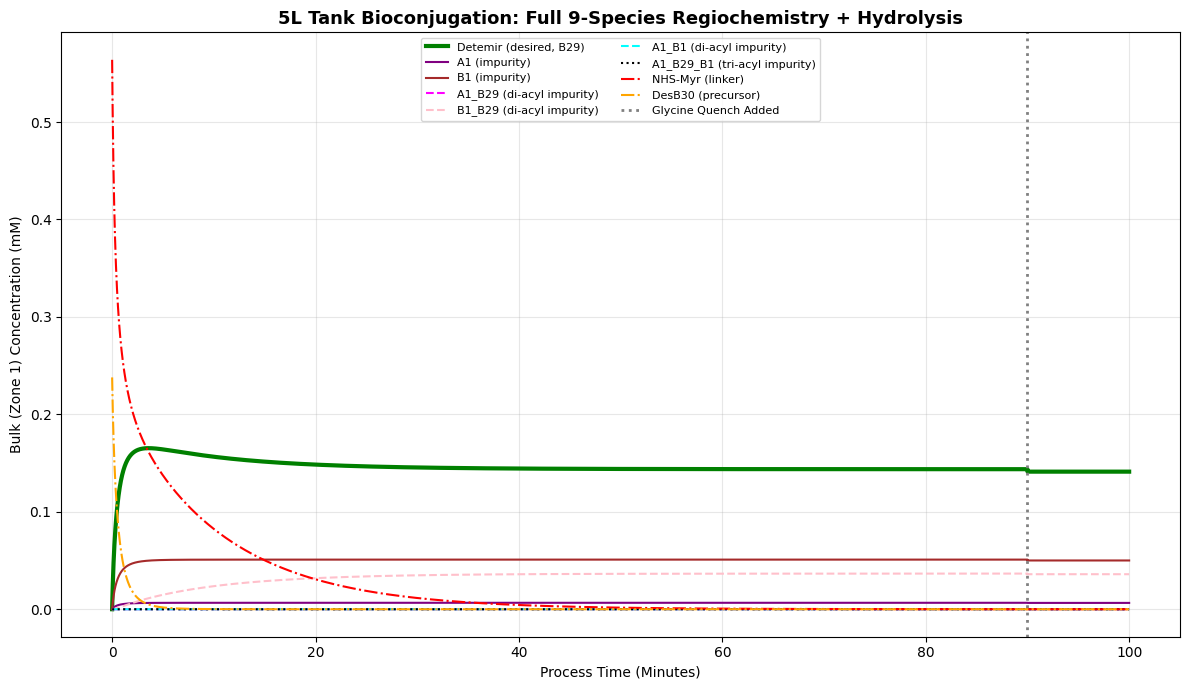

In [9]:
t_comb_min = np.concatenate((t_rxn, t_quench)) / 60.0
bulk = lambda name: np.concatenate((y_rxn[IDX[name], 0, :], y_quench[IDX[name], 0, :]))

plt.figure(figsize=(12, 7))
plt.plot(t_comb_min, bulk('detemir'), label='Detemir (desired, B29)', color='green', linewidth=3)
plt.plot(t_comb_min, bulk('A1'), label='A1 (impurity)', color='purple')
plt.plot(t_comb_min, bulk('B1'), label='B1 (impurity)', color='brown')
plt.plot(t_comb_min, bulk('A1_B29'), label='A1_B29 (di-acyl impurity)', color='magenta', linestyle='--')
plt.plot(t_comb_min, bulk('B1_B29'), label='B1_B29 (di-acyl impurity)', color='pink', linestyle='--')
plt.plot(t_comb_min, bulk('A1_B1'), label='A1_B1 (di-acyl impurity)', color='cyan', linestyle='--')
plt.plot(t_comb_min, bulk('A1_B29_B1'), label='A1_B29_B1 (tri-acyl impurity)', color='black', linestyle=':')
plt.plot(t_comb_min, bulk('nhs_myr'), label='NHS-Myr (linker)', color='red', linestyle='-.')
plt.plot(t_comb_min, bulk('desb30'), label='DesB30 (precursor)', color='orange', linestyle='-.')
plt.axvline(x=90.0, color='gray', linestyle=':', linewidth=2, label='Glycine Quench Added')
plt.title('5L Tank Bioconjugation: Full 9-Species Regiochemistry + Hydrolysis', fontsize=13, fontweight='bold')
plt.xlabel('Process Time (Minutes)')
plt.ylabel('Bulk (Zone 1) Concentration (mM)')
plt.legend(fontsize=8, ncol=2)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()